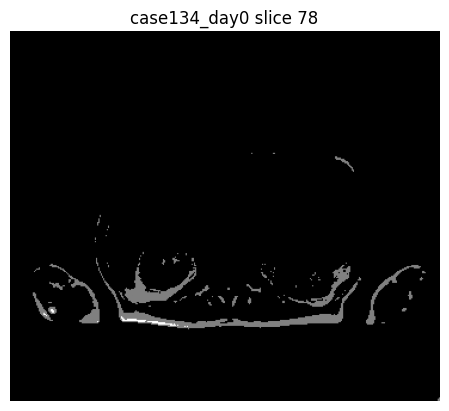

In [23]:
from src.data_utils import build_case_day_slices, build_rle_index
from src.datasets import LoadCaseDayVolumed
from monai.transforms import Compose, EnsureChannelFirstd, EnsureTyped
import matplotlib.pyplot as plt
import cv2

data_root = "./inputs"
train_dir = f"{data_root}/train"
train_csv = f"{data_root}/train.csv"

case_day_slices = build_case_day_slices(train_dir)
rle_index = build_rle_index(train_csv)

# 选一个 case_day
case_day = "case134_day0"

# 用 LoadCaseDayVolumed 读完整 volume
tx = Compose([
    LoadCaseDayVolumed(keys=["case_day"], case_day_slices=case_day_slices, rle_index=rle_index),
    EnsureChannelFirstd(keys=["image"], channel_dim="no_channel"),
    EnsureTyped(keys=["image", "label"]),
])
sample = tx({"case_day": case_day})

# image shape: (C, D, H, W)，这里 C=1
img_vol = sample["image"][0]  # (D, H, W)
label_vol = sample["label"]   # (C, D, H, W)

# 按 slice index 画
slice_idx = 78
plt.imshow(img_vol[slice_idx], cmap="gray")
plt.title(f"{case_day} slice {slice_idx}")
plt.axis("off")
plt.show()


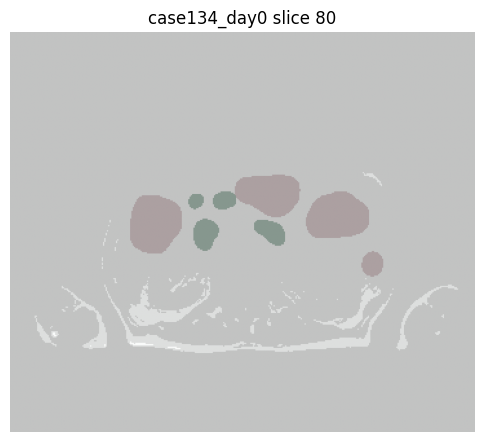

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# img_vol: (D,H,W)
# label_vol: (C,D,H,W)
slice_idx = 80

img = img_vol[slice_idx]
mask = label_vol[:, slice_idx]  # (C,H,W)

# 颜色（和 val_infer_dice.py 一致）
cmaps = ["Reds", "Greens", "Blues"]
alpha = 0.4

plt.figure(figsize=(6,6))
plt.imshow(img, cmap="gray")
for c in range(mask.shape[0]):
    plt.imshow(mask[c], cmap=cmaps[c], alpha=alpha)
plt.title(f"{case_day} slice {slice_idx}")
plt.axis("off")
plt.show()


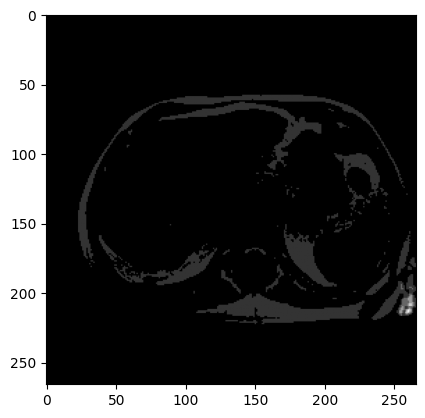

In [21]:
img = cv2.imread('inputs/train/case101/case101_day20/scans/slice_0078_266_266_1.50_1.50.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img,cmap='gray')


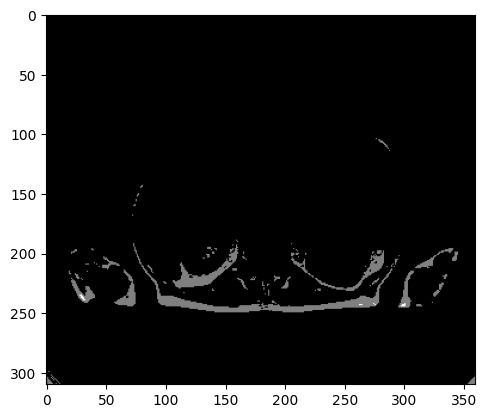

In [24]:
img = cv2.imread('inputs/train/case134/case134_day0/scans/slice_0074_360_310_1.50_1.50.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img,cmap='gray')


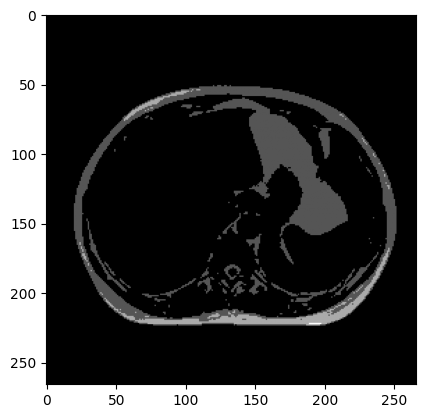

In [25]:
img = cv2.imread('inputs/train/case156/case156_day11/scans/slice_0078_266_266_1.50_1.50.png',cv2.IMREAD_GRAYSCALE)
plt.imshow(img,cmap='gray')
